In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path().resolve().parents[1]  # ajusta se necessário
sys.path.append(str(ROOT))

from mia_rl.envs.gridworld import Gridworld, ACTIONS, ARROW
from mia_rl.agents.planning.gridworld import (
    uniform_random_policy,
    policy_evaluation,
    policy_improvement,
    policy_iteration,
)
from mia_rl.plots.gridworld import plot_grid, plot_policy_iteration_history

np.set_printoptions(precision=3, suppress=True)

## 1) Ambiente — Gridworld

Grelha 4×4 com estados terminais em (0,0) e (3,3).  
Recompensa: −1 por cada passo; 0 nos terminais.  
Transição: determinista; bater na parede → ficar no mesmo sítio.

In [2]:
env = Gridworld()
env.states()[:5], env.terminal_states

([(0, 0), (0, 1), (0, 2), (0, 3), (1, 0)], ((0, 0), (3, 3)))

## 2) Avaliação de Política — política aleatória uniforme

$V(s) \leftarrow \sum_a \pi(a|s)\big[r(s,a) + \gamma V(s')\big]$

In [3]:
gamma = 0.9

pi0 = uniform_random_policy(env)
# print('π(a|s) em (1,1):', pi0[(1,1)])
pi0[(1,1)]

{'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25}

In [4]:
V_pi0, iters = policy_evaluation(env, pi0, gamma=gamma)
print('Policy evaluation converged in iterations:', iters)
V_pi0

Policy evaluation converged in iterations: 118


array([[ 0.   , -5.278, -7.128, -7.651],
       [-5.278, -6.606, -7.181, -7.128],
       [-7.128, -7.181, -6.606, -5.278],
       [-7.651, -7.128, -5.278,  0.   ]])

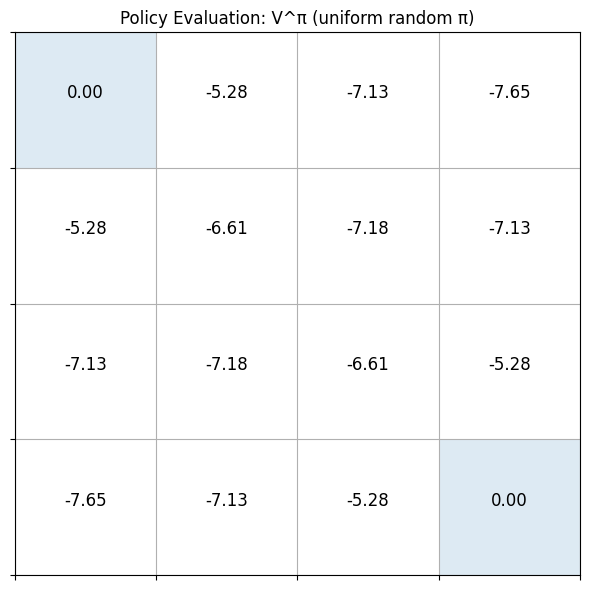

In [5]:
plot_grid(env, V_pi0, policy=None, title='Policy Evaluation: V^π (uniform random π)')
plt.show()

## 3) Melhoria de Política

$\pi'(s) = \arg\max_a \big[r(s,a) + \gamma V(s')\big]$

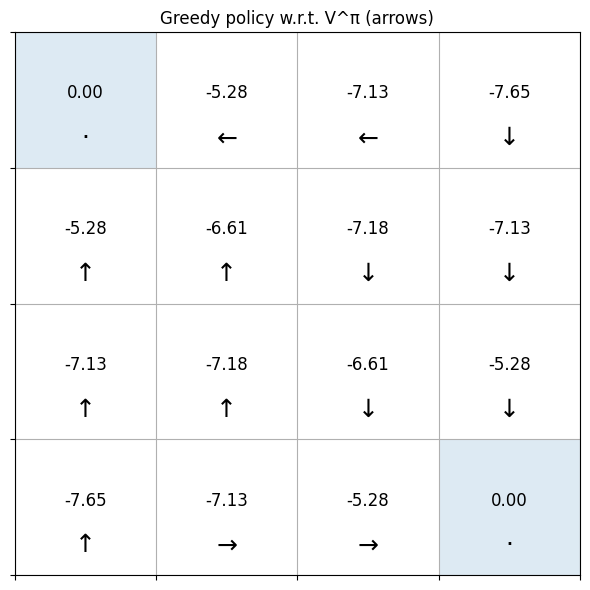

In [6]:
pi1_actions, _ = policy_improvement(env, V_pi0, old_policy_actions=None, gamma=gamma)
plot_grid(env, V_pi0, policy=pi1_actions, title='Greedy policy w.r.t. V^π (arrows)')
plt.show()

## Policy Iteration

Repeat until stable:

1) **Policy Evaluation:** compute $(V^\pi)$ for current policy  
2) **Policy Improvement:** greedify to get a better policy

This converges to an optimal policy in finite MDPs.

In [7]:
V_star, pi_star_actions, hist = policy_iteration(env, gamma=gamma)
print('Policy iteration outer loops:', len(hist))
print(V_star)

Policy iteration outer loops: 3
[[ 0.   -1.   -1.9  -2.71]
 [-1.   -1.9  -2.71 -1.9 ]
 [-1.9  -2.71 -1.9  -1.  ]
 [-2.71 -1.9  -1.    0.  ]]


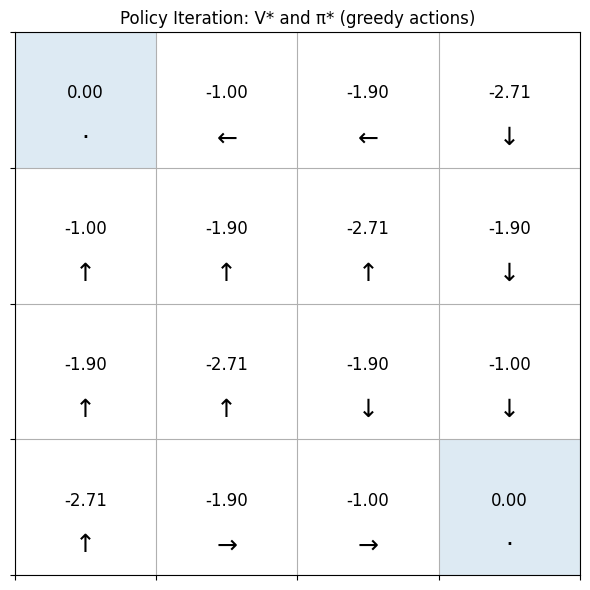

In [8]:
plot_grid(env, V_star, policy=pi_star_actions, title='Policy Iteration: V* and π* (greedy actions)')
plt.show()

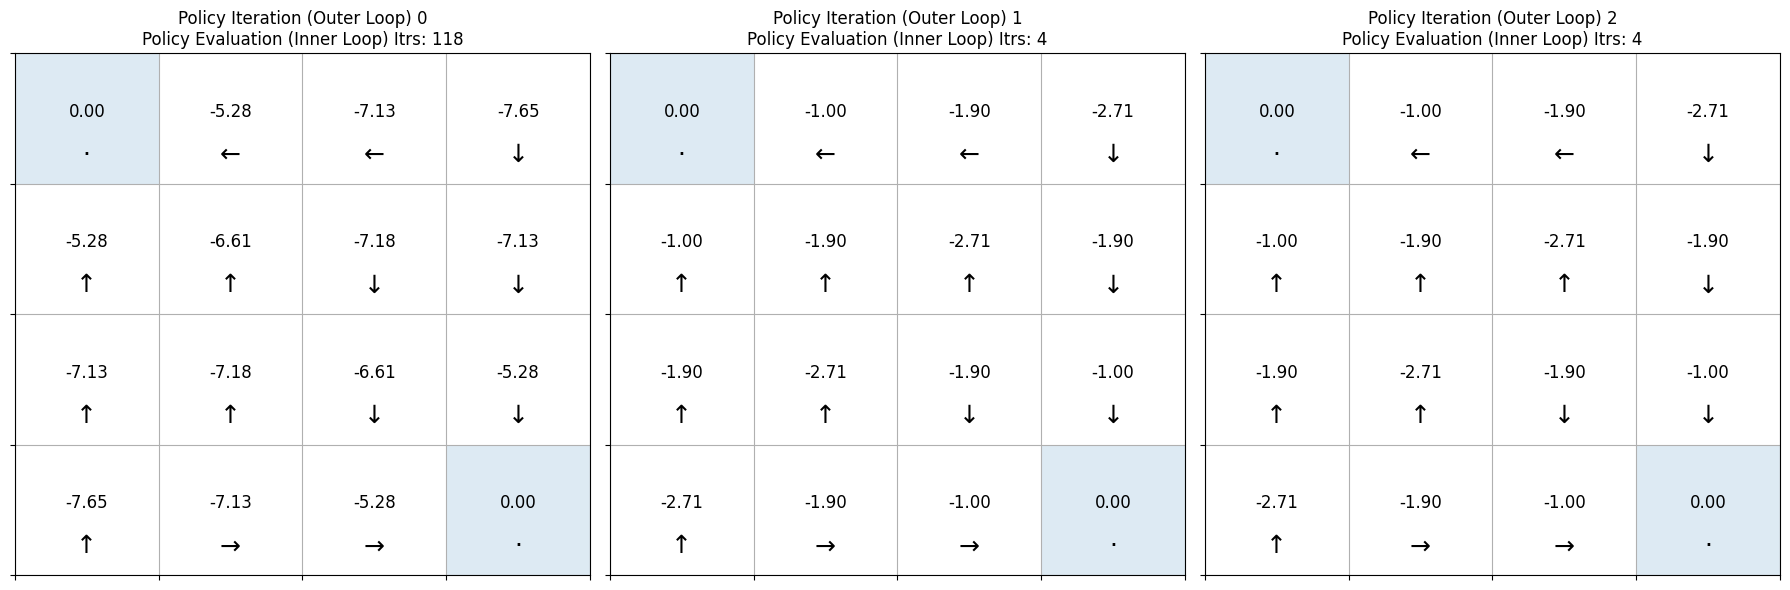

In [9]:
fig = plot_policy_iteration_history(env, hist)
plt.show()

In [10]:
print('Política óptima π*:')
for r in range(env.n_rows):
    row = [ARROW.get(pi_star_actions.get((r,c), '·'), '·') for c in range(env.n_cols)]
    print(' '.join(row))

Política óptima π*:
· ← ← ↓
↑ ↑ ↑ ↓
↑ ↑ ↓ ↓
↑ → → ·
